In [22]:
!pip install geopandas rioxarray rasterio xarray shapely matplotlib

In [23]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/Bioclimatic_Analysis")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
from src.config import *
from src.data_loader import *
from src.preprocessing import *
from src.stress_analysis import *
from src.occurrence_analysis import *
from src.visualization import *

In [27]:
moramanga, maroantsetra = load_districts(ADMIN_PATH)
occ_gdf = load_occurrences(OCC_PATH)

print("Total occurrences:", len(occ_gdf))
occ_gdf.head()

Total occurrences: 5556


,species,decimalLatitude,decimalLongitude,year,geometry
0,Bernieria madagascariensis,-21.265903,47.419315,2013.0,POINT (47.41932 -21.2659)
1,Bernieria madagascariensis,-18.834978,48.458736,2013.0,POINT (48.45874 -18.83498)
2,Bernieria madagascariensis,-21.238163,47.385765,2013.0,POINT (47.38576 -21.23816)
3,Bernieria madagascariensis,-16.267284,46.851080,2013.0,POINT (46.85108 -16.26728)
4,Bernieria madagascariensis,-18.834978,48.458736,2013.0,POINT (48.45874 -18.83498)


In [28]:
occ_mora = extract_occurrences(occ_gdf, moramanga)
occ_maro = extract_occurrences(occ_gdf, maroantsetra)

print("Occurrences Moramanga:", len(occ_mora))
print("Occurrences Maroantsetra:", len(occ_maro))

Occurrences Moramanga: 1640
Occurrences Maroantsetra: 217


In [29]:
for var in VARIABLES:
    print(f"Clipping variable {var}...")
    safe_clip(var, moramanga, "Moramanga", CLIMATE_PATH, CLIMATE_PATH)
    safe_clip(var, maroantsetra, "Maroantsetra", CLIMATE_PATH, CLIMATE_PATH)

print("Clipping terminé.")

Clipping variable 1...
Clipping variable 12...
Clipping variable 15...
Clipping variable 18...
Clipping variable 19...
Clipping terminé.


In [30]:
bio12_mora = load_clipped_raster(12, "Moramanga", CLIMATE_PATH)
bio15_mora = load_clipped_raster(15, "Moramanga", CLIMATE_PATH)
bio19_mora = load_clipped_raster(19, "Moramanga", CLIMATE_PATH)

bio12_maro = load_clipped_raster(12, "Maroantsetra", CLIMATE_PATH)
bio15_maro = load_clipped_raster(15, "Maroantsetra", CLIMATE_PATH)
bio19_maro = load_clipped_raster(19, "Maroantsetra", CLIMATE_PATH)

In [31]:
print("Moramanga humid mean:",
      float(bio19_mora.mean(dim=["x","y"])))

print("Maroantsetra humid mean:",
      float(bio19_maro.mean(dim=["x","y"])))

Moramanga humid mean: 172.63670349121094
Maroantsetra humid mean: 307.1309814453125


In [32]:
thresholds_mora = compute_thresholds(
    bio12_mora, bio15_mora, bio19_mora
)

print("Moramanga thresholds:")
print("Bio12 low:", thresholds_mora[0])
print("Bio15 high:", thresholds_mora[1])
print("Bio19 low:", thresholds_mora[2])

Moramanga thresholds:
Bio12 low: 1516.0
Bio15 high: 87.98545
Bio19 low: 108.0


In [33]:
thresholds_maro = compute_thresholds(
    bio12_maro, bio15_maro, bio19_maro
)

print("Maroantsetra thresholds:")
print("Bio12 low:", thresholds_maro[0])
print("Bio15 high:", thresholds_maro[1])
print("Bio19 low:", thresholds_maro[2])

Maroantsetra thresholds:
Bio12 low: 1838.0
Bio15 high: 74.644806
Bio19 low: 168.0


In [34]:
stress_index_mora = compute_stress_index(
    bio12_mora, bio15_mora, bio19_mora,
    *thresholds_mora
)

In [35]:
stress_index_maro = compute_stress_index(
    bio12_maro, bio15_maro, bio19_maro,
    *thresholds_maro
)

/tmp/ipython-input-3893384633.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask["geometry"] = mask.geometry.difference(region.unary_union)
/tmp/ipython-input-3893384633.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask["geometry"] = mask.geometry.difference(region.unary_union)


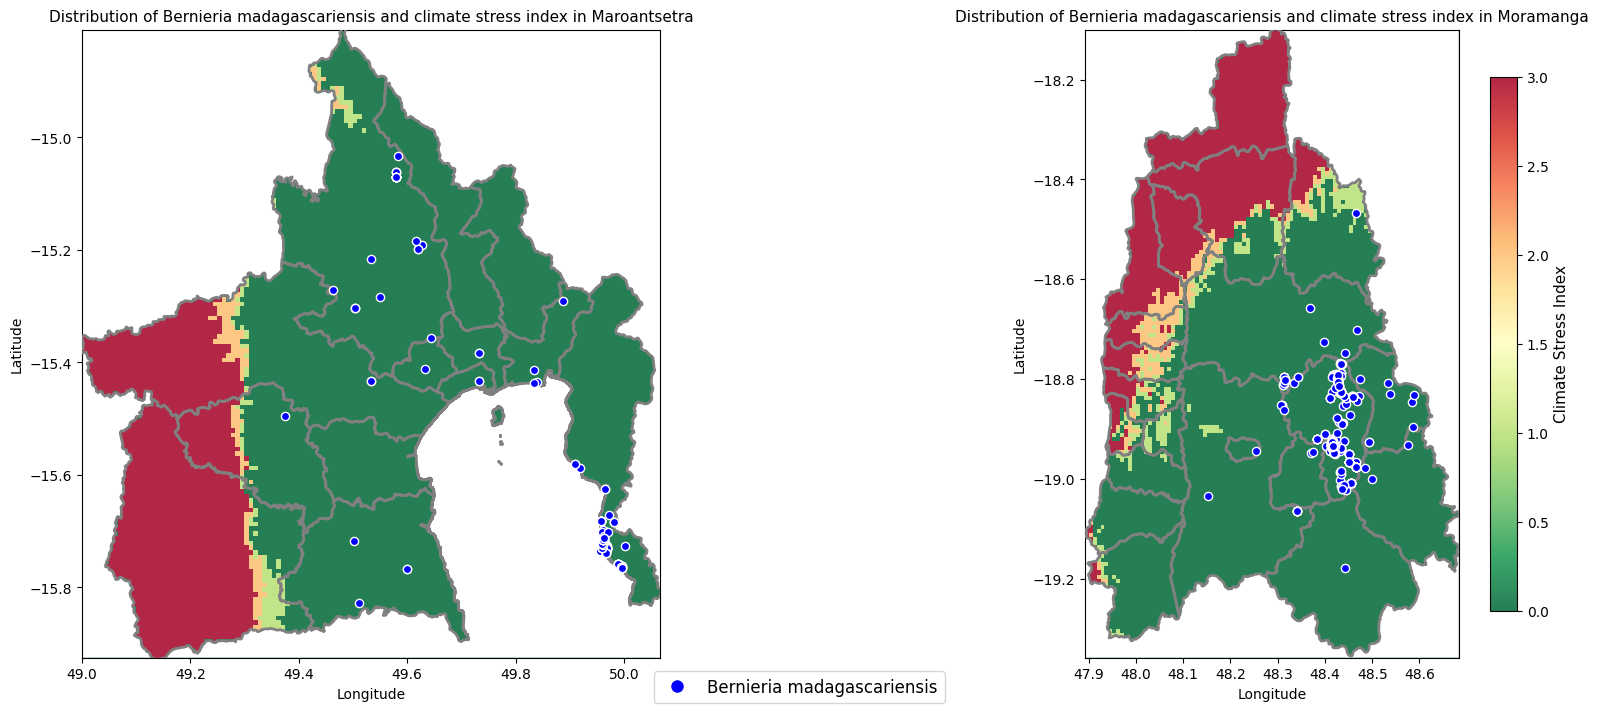

In [36]:
def plot_stress_map_comparison(
    stress_index_maro,
    maroantsetra,
    occ_maro,
    stress_index_mora,
    moramanga,
    occ_mora,
    output_path
):

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(17,7),
        constrained_layout=True
    )

    datasets = [
        (stress_index_maro, maroantsetra, occ_maro, "Maroantsetra"),
        (stress_index_mora, moramanga, occ_mora, "Moramanga")
    ]

    mappable = None

    for ax, (raster, region, occ, title) in zip(axes, datasets):

        ax.set_facecolor("white")

        # Raster
        im = raster.plot(
            ax=ax,
            cmap="RdYlGn_r",
            alpha=0.85,
            add_colorbar=False,
            zorder=1
        )
        mappable = im

        # Mask extérieur
        xmin, ymin, xmax, ymax = raster.rio.bounds()
        full_extent = box(xmin, ymin, xmax, ymax)

        mask = gpd.GeoDataFrame(
            geometry=[full_extent],
            crs=region.crs
        )
        mask["geometry"] = mask.geometry.difference(region.unary_union)
        mask.plot(ax=ax, color="white", zorder=2)

        # Limites
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        # Contours région
        region.boundary.plot(
            ax=ax,
            color="grey",
            linewidth=2,
            zorder=3
        )

        # Occurrences
        occ.plot(
            ax=ax,
            color="blue",
            markersize=35,
            edgecolor="white",
            linewidth=1,
            zorder=10
        )

        ax.set_title(
            f"Distribution of Bernieria madagascariensis and climate stress index in {title}",
            fontsize=11
        )
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Colorbar commune
    cbar = fig.colorbar(
        mappable,
        ax=axes,
        orientation="vertical",
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label("Climate Stress Index", fontsize=11)

    # Légende espèce
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            label='Bernieria madagascariensis',
            markerfacecolor='blue',
            markeredgecolor='white',
            markersize=10
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=1,
        frameon=True,
        fontsize=12
    )

    # Sauvegarde
    filename = "stress_climatique_distribution_Bernieria_madagascariensis.png"
    file_path = os.path.join(output_path, filename)

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

plot_stress_map_comparison(
    stress_index_maro,
    maroantsetra,
    occ_maro,
    stress_index_mora,
    moramanga,
    occ_mora,
    OUTPUT_PATH
)